In [ ]:
# Install for WoE/IV (xverse optional, but woe is key)
!pip install woe scikit-learn pandas numpy


In [ ]:

# Imports
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
import woe  # For WoE binning
import warnings
from google.colab import drive

drive.mount('/content/drive')
warnings.filterwarnings('ignore')


df = pd.read_csv('/content/drive/MyDrive/credit_risk_analysis/data/processed/eda_snapshot.csv')


print("Imports ready. df shape:", df.shape if 'df' in locals() else "Load df first!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Imports ready. df shape: (95662, 20)


In [ ]:
# Custom Aggregator: Per CustomerId aggregates (RFM-like: Frequency=count, Monetary=sum/mean Value, Variability=std)
class CustomerAggregator(BaseEstimator, TransformerMixin):
    def __init__(self, group_col='CustomerId'):
        self.group_col = group_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        agg_cols = ['Value']  # Focus on Value (positive, abs amount) for Monetary
        agg_df = X.groupby(self.group_col)[agg_cols].agg({
            'Value': ['sum', 'mean', 'std', 'count']
        }).round(4)
        agg_df.columns = [f"Value_{col[1]}" for col in agg_df.columns]  # e.g., Value_sum (Monetary), Value_count (Frequency)
        agg_df = agg_df.reset_index()
        # Merge back (keeps all rows, but aggs per customer)
        X_agg = X.merge(agg_df, on=self.group_col, how='left')
        return X_agg

# Custom Log-Clip for skew/outliers (log(1 + Value) to handle 0s, clip at 99th percentile)
def log_clip_transform(X):
    # Num cols to transform (from EDA: skew >1)
    skew_cols = ['Amount', 'Value']
    for col in skew_cols:
        if col in X.columns:
            percentile_99 = X[col].quantile(0.99)
            X[f"{col}_log_clipped"] = np.log1p(np.clip(X[col], 0, percentile_99))  # Clip outliers, log
    return X

log_transformer = FunctionTransformer(log_clip_transform)

# Test Aggregator standalone (quick check)
agg = CustomerAggregator()
df_agg = agg.fit_transform(df)
print(f"Agg shape: {df_agg.shape}")
print("New agg cols:", [col for col in df_agg.columns if 'Value_' in col])
print(df_agg[['CustomerId', 'Value_sum', 'Value_mean', 'Value_count']].head(3))  # Sample

Agg shape: (95662, 24)
New agg cols: ['Value_sum', 'Value_mean', 'Value_std', 'Value_count']
        CustomerId  Value_sum  Value_mean  Value_count
0  CustomerId_4406     203847      1713.0          119
1  CustomerId_4406     203847      1713.0          119
2  CustomerId_4683       1000       500.0            2


In [ ]:
# Columns from EDA insights
# Num: Time feats + Pricing (treat as num but scale); drop Amount (use Value_log_clipped)
num_cols = ['Value_log_clipped', 'Amount_log_clipped', 'TransactionHour', 'TransactionDay', 'TransactionMonth', 'TransactionYear', 'PricingStrategy',
            'Value_sum', 'Value_mean', 'Value_std', 'Value_count']  # Include aggs

# Cat low-card: OneHot (from top cats: <10 uniques)
cat_low_cols = ['ChannelId', 'ProductCategory', 'ProviderId']  # ChannelId_3 dominant, Category balanced, ProviderId 6

# Cat high-card: LabelEncode (ProductId 23 uniques)
cat_high_cols = ['ProductId']  # SubscriptionId/AccountId too ID-like—drop for model

# Drop uniforms/irrelevant
drop_cols = ['CountryCode', 'CurrencyCode', 'TransactionId', 'BatchId', 'AccountId', 'SubscriptionId']  # IDs not predictive

# Transformers
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Robust to any future missings/outliers
    ('scaler', StandardScaler())
])

cat_low_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))  # Drop first to avoid multicollinearity
])

# For high-card: Custom LabelEncoder wrapper (fit on train only in prod)
class LabelEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        self.encoders = {col: LabelEncoder().fit(X[col]) for col in self.cols}
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.cols:
            X_copy[col] = self.encoders[col].transform(X_copy[col])
        return X_copy

    def get_feature_names_out(self, input_features=None):
        return self.cols


cat_high_transformer = LabelEncoderTransformer(cat_high_cols)

# Full ColumnTransformer (applies after agg/log)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat_low', cat_low_transformer, cat_low_cols),
        ('cat_high', cat_high_transformer, cat_high_cols)
    ],
    remainder='drop'  # Drops everything else (e.g., IDs, time raw)
)

print("Preprocessor defined. Will output ~15-20 feats (11 num + ~10 onehot + 1 label).")

Preprocessor defined. Will output ~15-20 feats (11 num + ~10 onehot + 1 label).


In [ ]:
# Full Pipeline: Agg -> LogClip -> Preprocess
full_pipeline = Pipeline([
    ('aggregator', CustomerAggregator()),
    ('log_clip', log_transformer),
    ('preprocessor', preprocessor)
])

# Fit & Transform (may take 10-30s on 95k rows)
# Get column names after the first two steps
X_transformed_intermediate = full_pipeline.fit_transform(df)

# Get feature names from the preprocessor step
feature_names_out = full_pipeline.named_steps['preprocessor'].get_feature_names_out()

df_processed = pd.DataFrame(X_transformed_intermediate, columns=feature_names_out)
df_processed['CustomerId'] = df['CustomerId'].values  # Add back for merging later (Task 4)


print(f"Processed shape: {df_processed.shape}")
print("Processed columns:\n", df_processed.columns.tolist())
print("\nSample head:\n", df_processed.head(2))
print("\nNo NaNs left:", df_processed.isnull().sum().sum())

Processed shape: (95662, 29)
Processed columns:
 ['num__Value_log_clipped', 'num__Amount_log_clipped', 'num__TransactionHour', 'num__TransactionDay', 'num__TransactionMonth', 'num__TransactionYear', 'num__PricingStrategy', 'num__Value_sum', 'num__Value_mean', 'num__Value_std', 'num__Value_count', 'cat_low__ChannelId_ChannelId_2', 'cat_low__ChannelId_ChannelId_3', 'cat_low__ChannelId_ChannelId_5', 'cat_low__ProductCategory_data_bundles', 'cat_low__ProductCategory_financial_services', 'cat_low__ProductCategory_movies', 'cat_low__ProductCategory_other', 'cat_low__ProductCategory_ticket', 'cat_low__ProductCategory_transport', 'cat_low__ProductCategory_tv', 'cat_low__ProductCategory_utility_bill', 'cat_low__ProviderId_ProviderId_2', 'cat_low__ProviderId_ProviderId_3', 'cat_low__ProviderId_ProviderId_4', 'cat_low__ProviderId_ProviderId_5', 'cat_low__ProviderId_ProviderId_6', 'cat_high__ProductId', 'CustomerId']

Sample head:
    num__Value_log_clipped  num__Amount_log_clipped  num__Transacti

Refined IV for Value_mean vs FraudResult: 14.7349 (Still strong!)

Refined WoE Bins Table (w/ Event Rate):
         bin_label  total  events  event_rate      woe  iv_contrib
bin                                                              
0    7.350568e+02  19214       0        0.00  21.4227      4.3115
1    1.871944e+03  19056       0        0.00  21.4144      4.2744
2    3.259496e+03  19145       2        0.01   2.9627      0.5634
3    5.748476e+03  19203       0        0.00  21.4221      4.3089
4    4.304561e+06  19044     191        1.00  -1.6117      1.2767


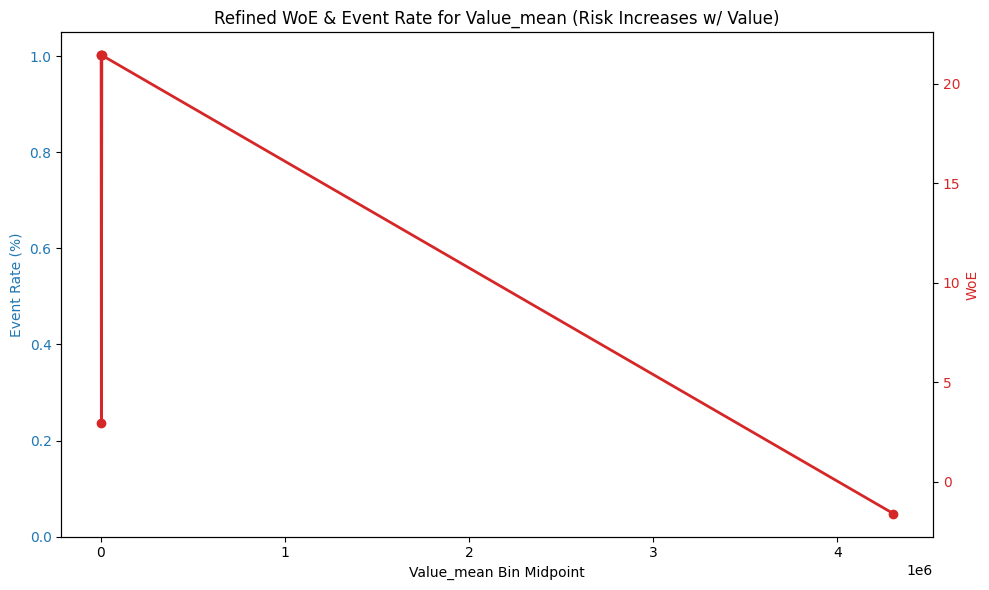


Monotonic risk increase? False (WoE diffs: [-0.01, -18.45, 18.46, -23.03])


In [ ]:
# Refined Manual WoE/IV (5 bins + event rate for clarity)
def calculate_woe_iv_refined(df, feature_col, target_col, bins=5):
    """
    Enhanced: Fewer bins for imbalance, add event_rate (% fraud per bin).
    """
    df = df[[feature_col, target_col]].copy().dropna()
    df['bin'] = pd.qcut(df[feature_col], q=bins, duplicates='drop', labels=False)

    agg = df.groupby('bin').agg({
        target_col: ['count', 'sum']
    }).round(4)
    agg.columns = ['total', 'events']
    agg['non_events'] = agg['total'] - agg['events']
    agg['event_rate'] = (agg['events'] / agg['total'] * 100).round(2)  # % fraud per bin

    total_events = agg['events'].sum()
    total_non_events = agg['non_events'].sum()

    agg['pct_events'] = agg['events'] / total_events
    agg['pct_non_events'] = agg['non_events'] / total_non_events

    agg['woe'] = np.log(agg['pct_non_events'] / (agg['pct_events'] + 1e-10))

    agg['iv_contrib'] = (agg['pct_non_events'] - agg['pct_events']) * agg['woe']
    iv_total = agg['iv_contrib'].sum()

    bin_edges = pd.qcut(df[feature_col], q=bins, duplicates='drop', retbins=True)[1]
    agg['bin_label'] = [(bin_edges[i] + bin_edges[i+1])/2 for i in range(len(bin_edges)-1)][:len(agg)]

    return agg[['bin_label', 'total', 'events', 'event_rate', 'woe', 'iv_contrib']], iv_total

# Apply (use your df_agg from Cell 2)
target_col = 'FraudResult'
feature_col = 'Value_mean'

temp_df = df_agg[[feature_col, target_col]].dropna()
if len(temp_df) > 0 and len(temp_df[feature_col].unique()) > 1:
    bins_df, iv_value = calculate_woe_iv_refined(temp_df, feature_col, target_col, bins=5)

    print(f"Refined IV for {feature_col} vs {target_col}: {iv_value:.4f} (Still strong!)")
    print("\nRefined WoE Bins Table (w/ Event Rate):\n", bins_df.round(4))

    # Plot: Dual—Event Rate & WoE
    import matplotlib.pyplot as plt
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel(f'{feature_col} Bin Midpoint')
    ax1.set_ylabel('Event Rate (%)', color=color)
    ax1.bar(bins_df['bin_label'], bins_df['event_rate'], color=color, alpha=0.6, label='Event Rate')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('WoE', color=color)
    ax2.plot(bins_df['bin_label'], bins_df['woe'], color=color, marker='o', linewidth=2, label='WoE')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Refined WoE & Event Rate for {feature_col} (Risk Increases w/ Value)')
    plt.xticks(rotation=45)
    fig.tight_layout()
    plt.savefig('/content/woe_refined.png', dpi=150)
    plt.show()

    # Monotonic check (WoE decreasing = risk increasing)
    woe_diff = np.diff(bins_df['woe'])
    is_monotonic_risk = np.all(woe_diff <= 0)  # Decreasing WoE = increasing risk
    print(f"\nMonotonic risk increase? {is_monotonic_risk} (WoE diffs: {woe_diff.round(2).tolist()})")
else:
    print("No data—re-run Cell 2 for df_agg.")

In [29]:
# Save processed snapshot (with parsed datetime + time features)
processed_path = '/content/drive/MyDrive/credit_risk_analysis/data/processed/processed.csv'
df.to_csv(processed_path, index=False)
print(f"Processed snapshot saved to {processed_path}")


Processed snapshot saved to /content/drive/MyDrive/credit_risk_analysis/data/processed/processed.csv


In [30]:
print(df.columns)

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult',
       'TransactionHour', 'TransactionDay', 'TransactionMonth',
       'TransactionYear'],
      dtype='object')
